In [1]:
from resources.imports import *
from openpyxl import load_workbook

from resources.lattices import Geometry, pStrainProperties, effProperties
from resources.calculations import get_ductileData, get_fractureData, calcUT, calcFT, plot_curve

In [2]:
LAT = "hex"
MODEL = "both"
l = 0.01  # m
nnx = 20
rD = 0.2

dis = 'per'
dn = 0.2
nSim = '1'

validation = False
psc = False
mesh = False

PATH_ADD = "sApp"

# os.chdir(f"Z:\\p1\\data\\Ti\\{dis}\\{PATH_ADD}\\0.2\\{LAT}")
os.chdir(f"Z:\\p1\\sims\\Ti\\{PATH_ADD}")
# os.chdir(r"C:\temp")

if validation:
    os.chdir(r"Z:\p1\sims\Ti\validation\\"+str(int(l*1000))+'\\'+str(rD))
    dis, nSim = 'per', '1'
elif psc:
    os.chdir(r"Z:\p1\sims\Ti\PSC\\"+str(int(l*1000)))
    dis, nSim = 'per', '1'
elif mesh:
    brackets = 1
    coarse = 1
    fine = 1
    os.chdir(r"Z:\p1\sims\Ti\MeshConv\\"+f"{brackets}-{coarse}-{fine}")
    dis, nSim = 'per', '1'

In [3]:
### CONVERGENCE STUDIES

# sim = 6

# start_row = 67
# cell_row = start_row + sim

# sheet_name = "PSC"
# column = ["G", "H", "I", "K", "L", "M", "N"]

# nnxs = [10, 16, 20, 26, 30, 36, 40]
# nnx = nnxs[sim]


# sheet_name = "MeshConv"
# column = ["K", "L", "M", "O", "P", "Q", "R"]

# coarses = [1, 2, 5]
# fines = [1, 2, 5, 10 ,15, 20, 25]

# coarse = coarses[sim//len(fines)]
# fine = fines[sim%len(fines)]

# os.chdir(r"Z:\\p1\\sims\\Ti\MeshConv\\1-"+str(coarse)+"-"+str(fine))

In [4]:
geom = Geometry(LAT, l, nnx)
geom.FTcalc()

E = 123000e6  ## Pa
v = 0.3
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(LAT, E_pStrain, rD)

In [5]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both": 
    CSVout = f"transfer\OUT-Ductile-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    UTdf = get_ductileData(CSVout, crit=0.25)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Fracture-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    FTdf = get_fractureData(CSVout)

In [6]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    ductility, strength, stiffness, WoF = calcUT(UTdf)
    print(ductility, strength, stiffness, WoF)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    P, dd, Ks, Kjs = calcFT(FTdf, geom, E_eff, n_Ks=1, validation=validation, E=E)
    Kic, Kjic = Ks[0], Kjs[0]
    print(P, dd, Kic/(10**6), Kjic/(10**6))

0.07767652314284752 18.85615916772844 1172.874303550164 0.9912167501419875
131167.00625 0.03169354248046875 17.3687829691241 21.599079083755633


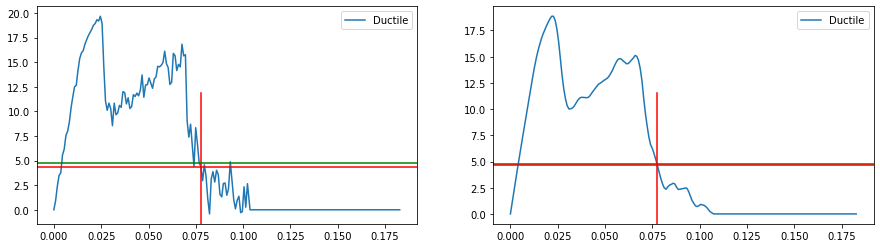

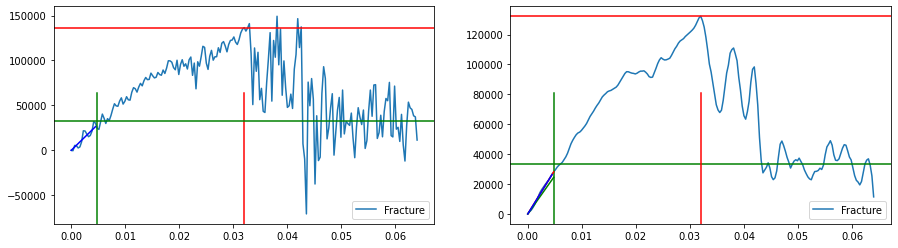

In [7]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plot_curve([UTdf], typ="ut", label="Ductile")

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plot_curve([FTdf], typ="ft", label="Fracture")

In [8]:
# ### WRITE TO EXCEL

# file_path = "C:/Users/exy053/OneDrive - Queen Mary, University of London/Documents/Research/p1-LatticeFractureToughness/Ductility-FractureToughness.xlsx"
# cell_coords = [f"{column[0]}{cell_row}", f"{column[1]}{cell_row}", f"{column[2]}{cell_row}", f"{column[3]}{cell_row}", f"{column[4]}{cell_row}", f"{column[5]}{cell_row}", f"{column[6]}{cell_row}"]
# values_to_write = [stiffness, strength, ductility, P, dd, Kic/(10**6), Kjic/(10**6)]

# # --- Load workbook and target sheet ---
# wb = load_workbook(file_path)
# ws = wb[sheet_name]  # Raises KeyError if the sheet doesn't exist

# # --- Write values ---
# for coord, value in zip(cell_coords, values_to_write):
#     ws[coord] = value

# # --- Save workbook ---
# wb.save(file_path)
# wb.close()

In [9]:
# ### SIM COMPARISON

# append = True
# appendReset = False
# if appendReset:
#     UTsave, FTsave = [], []

# if MODEL.lower() == "ductile" or MODEL.lower() == "both":
#     if append:
#         UTsave.append([UTdf, ductility, strength, stiffness])
#         plot_curve(np.array(UTsave, dtype=object)[:,0], typ="UT")


# if MODEL.lower() == "fracture" or MODEL.lower() == "both":
#     if append:
#         FTsave.append([FTdf, P, dd, Ks, Kjs])
#         plot_curve(np.array(FTsave, dtype=object)[:,0], typ="FT")

In [10]:
# ### NORMALIZATION of Ks

# s_ts = (932*(1+(0.1105-(932/123000))**0.7237)) * 10**6  # 

# K_norm = Kic/(s_ts)
# K_norml = Kic/(s_ts*((l)**0.5))
# Kj_norm = Kjic/(s_ts)
# Kj_norml = Kjic/(s_ts*((l)**0.5))

# K_norm, K_norml, Kj_norm, Kj_norml